# Helmet Detection — Training & Evaluation (Phase 2–3)

**Repo:** `helmet-detection-system` · **PRD:** `docs/requirements/PRD.md` · **TDD:** `docs/architecture/TDD.md`
· **Plan:** `docs/workflow/implementation_plan.md`

Single notebook covering the merged Phase 2–3: dataset loading → statistics → training config →
live epoch tracking → training metrics → validation metrics → model evaluation → error analysis →
save `best.pt` → export.

Run the cells **in order**, top to bottom.

---

## ⚠️ Read before running

**1. Privacy (PRD open question #3).** This notebook uploads your dataset to Google Colab.
Your data is **custom factory footage of identifiable workers**. If OQ3 resolves to
*on-prem-only storage*, **Colab is not a legal venue for this training run** — move to a local or
on-prem GPU. Resolve OQ3 *before* you upload anything. Deleting it afterwards does not undo it.

**2. Phase gate (implementation plan §Phase 1).** This notebook needs a validated, split dataset in
`data/processed/{train,val,test}/` plus `data/metadata/`. If Phase 1's gate is not met, **stop** —
Section 2 will tell you what's missing, but a model trained on a leaky or unbalanced dataset
produces numbers that are worse than none, because they look trustworthy.

**3. Test-split discipline (the thing merging Phase 2 & 3 puts at risk).**
Iterate using the **validation** split (Section 6). The **test** split (Section 7) is behind an
explicit `RUN_TEST_EVAL` flag and is meant to be run **once**, when you believe you are done.
Every extra peek at test leaks information into your choices and quietly turns PRD §2.1 into a
number you can no longer trust. Sections 6 and 7 are separated for exactly this reason.

**4. Save before the VM dies.** Colab VMs are reclaimed without warning. Section 9 persists
artifacts — run it as soon as training finishes, not at the end of the day.

## 0 · Colab setup

Checks the GPU, gets the repo + dataset onto the machine, installs dependencies.

In [4]:
# GPU check — confirms what hardware this run actually got.
!nvidia-smi || echo "NO GPU — Runtime > Change runtime type > GPU. Training on CPU is not viable."

Thu Jul 16 15:33:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             13W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
import os, sys, subprocess
from pathlib import Path

# ── Repo (git clone onto Drive) + dataset (uploaded after cloning) ─────────────
# Clone the repo directly onto Drive so it persists across VM restarts and stays traceable to
# GIT_COMMIT (captured below) — configs/ and data/metadata/ come from this clone, since both
# are committed to git. data/processed/{train,val,test}/ is gitignored (size) and doesn't exist
# until YOU upload it into WORK_DIR/data/processed AFTER this cell creates WORK_DIR by cloning.
# Section 1's Phase-1-gate check will tell you clearly if it's still missing.
#
# TODO(you): confirm these before the first run.

REPO_URL = "https://github.com/arghads9177/helmet-detection-system"
WORK_DIR = Path("/content/drive/MyDrive/Data Science/Computer Vision/helmet-detection-system")

from google.colab import drive
drive.mount("/content/drive")

if not WORK_DIR.exists():
    WORK_DIR.parent.mkdir(parents=True, exist_ok=True)
    subprocess.run(["git", "clone", REPO_URL, str(WORK_DIR)], check=True)
else:
    print(f"{WORK_DIR} already exists — reusing it (not re-cloning).")

os.chdir(WORK_DIR)
sys.path.insert(0, str(WORK_DIR))

print("Working dir:", Path.cwd())
if not (WORK_DIR / "data" / "processed" / "train" / "images").is_dir():
    print("→ data/processed/{train,val,test}/ not found yet — upload the bundled dataset into")
    print(f"  {WORK_DIR / 'data' / 'processed'} now, before running Section 1.")

Mounted at /content/drive
/content/drive/MyDrive/Data Science/Computer Vision/helmet-detection-system already exists — reusing it (not re-cloning).
Working dir: /content/drive/MyDrive/Data Science/Computer Vision/helmet-detection-system


In [6]:
# Dependencies. Ultralytics pulls torch; Colab already has a CUDA torch.
!pip install -q ultralytics pyyaml pandas matplotlib seaborn

import ultralytics; ultralytics.checks()

Ultralytics 8.4.96 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 46.7/112.6 GB disk)


In [7]:
# Reproducibility + git provenance. The commit goes into metadata.json (Section 9) so any
# result can be traced back to the exact code that produced it.
import random, subprocess
import numpy as np

SEED = 42
random.seed(SEED); np.random.seed(SEED)
try:
    import torch; torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
except Exception:
    pass

try:
    GIT_COMMIT = subprocess.check_output(["git", "rev-parse", "--short", "HEAD"], text=True).strip()
    DIRTY = bool(subprocess.check_output(["git", "status", "--porcelain"], text=True).strip())
except Exception:
    GIT_COMMIT, DIRTY = "unknown", True

print(f"git commit: {GIT_COMMIT}{'  (DIRTY — uncommitted changes)' if DIRTY else ''}")
if DIRTY:
    print("⚠️  Uncommitted changes: this run will not be exactly reproducible from the commit.")

git commit: 775b686


## 1 · Dataset loading

Reads `configs/data.yaml` (repo config) and generates the **Ultralytics dataset YAML** from it.

Two different files, easy to confuse:
- `configs/data.yaml` — *our* config: paths, split ratios, class file. Source of truth.
- `configs/yolo_dataset.yaml` — *generated* here, the format Ultralytics needs. Never hand-edit.

In [8]:
import os, sys
import yaml
from pathlib import Path

# Defensive re-anchor: if Colab restarted the runtime after the pip-install cell (common with
# ultralytics/numpy version prompts), Section 0's os.chdir + sys.path.insert are gone in the
# fresh process — "from scripts..." would fail with ModuleNotFoundError. Re-establish both here
# so this cell works whether or not a restart happened in between.
try:
    WORK_DIR
except NameError:
    WORK_DIR = Path("/content/drive/MyDrive/Data Science/Computer Vision/helmet-detection-system")
os.chdir(WORK_DIR)
if str(WORK_DIR) not in sys.path:
    sys.path.insert(0, str(WORK_DIR))

from scripts.utilities.config import load_config   # shared helper — don't duplicate yaml.safe_load here

data_cfg = load_config("data")
ROOT = Path.cwd()
PROCESSED = ROOT / data_cfg["processed_dir"]
METADATA  = ROOT / data_cfg["metadata_dir"]

# Classes — data/metadata/class_names.txt is the source of truth (TDD §7).
classes_file = ROOT / data_cfg["classes_file"]
if not classes_file.exists():
    raise FileNotFoundError(f"{classes_file} missing — Phase 1 gate not met.")
CLASS_NAMES = [c.strip() for c in classes_file.read_text().splitlines() if c.strip()]

EXPECTED = ["helmet", "no_helmet"]
if CLASS_NAMES != EXPECTED:
    print(f"⚠️  class_names.txt is {CLASS_NAMES}, PRD §3 specifies {EXPECTED}.")
    print("    Class ORDER defines the label ids — a mismatch silently trains the wrong mapping.")

NO_HELMET_IDX = CLASS_NAMES.index("no_helmet") if "no_helmet" in CLASS_NAMES else None
print("Classes:", dict(enumerate(CLASS_NAMES)))

Classes: {0: 'helmet', 1: 'no_helmet'}


In [9]:
# Verify the Phase 1 gate before spending GPU time.
missing = [s for s in ("train", "val", "test") if not (PROCESSED / s / "images").is_dir()]
if missing:
    raise FileNotFoundError(
        f"Missing splits: {missing} under {PROCESSED}.\n"
        "Phase 1 gate unmet — run scripts/dataset_split/split_by_session.py first."
    )

# Generate the Ultralytics dataset YAML from configs/data.yaml.
yolo_yaml = {
    "path": str(PROCESSED.resolve()),
    "train": "train/images",
    "val": "val/images",
    "test": "test/images",
    "names": {i: n for i, n in enumerate(CLASS_NAMES)},
}
YOLO_YAML_PATH = ROOT / "configs" / "yolo_dataset.yaml"
with open(YOLO_YAML_PATH, "w") as f:
    yaml.safe_dump(yolo_yaml, f, sort_keys=False)

print(YOLO_YAML_PATH.read_text())

path: /content/drive/MyDrive/Data Science/Computer Vision/helmet-detection-system/data/processed
train: train/images
val: val/images
test: test/images
names:
  0: helmet
  1: no_helmet



## 2 · Dataset statistics

Not decoration — this section is a **gate**. It checks the two failure modes that make every
downstream number meaningless (implementation plan, R2 and R4):

- **Class imbalance** — too few `no_helmet` caps recall, and recall is the metric PRD §7 says matters.
- **Split leakage** — sessions spanning splits inflate every metric in PRD §2.1.

If either check fails, the correct action is to **go back to Phase 1**, not to train and hope.

In [10]:
import pandas as pd
from collections import Counter

IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def read_label(p: Path):
    """YOLO label file -> [(cls, cx, cy, w, h)]. Tolerates blank lines (negative samples)."""
    rows = []
    if not p.exists():
        return rows
    for line in p.read_text().splitlines():
        parts = line.split()
        if len(parts) >= 5:
            rows.append((int(parts[0]), *map(float, parts[1:5])))
    return rows

def scan_split(split: str) -> pd.DataFrame:
    img_dir = PROCESSED / split / "images"
    lbl_dir = PROCESSED / split / "labels"
    recs = []
    for img in sorted(p for p in img_dir.iterdir() if p.suffix.lower() in IMG_EXT):
        boxes = read_label(lbl_dir / f"{img.stem}.txt")
        if not boxes:
            recs.append({"split": split, "image": img.name, "stem": img.stem,
                         "cls": None, "w": None, "h": None})
        for c, _cx, _cy, w, h in boxes:
            recs.append({"split": split, "image": img.name, "stem": img.stem,
                         "cls": c, "w": w, "h": h})
    return pd.DataFrame(recs)

df = pd.concat([scan_split(s) for s in ("train", "val", "test")], ignore_index=True)

print("Images per split:")
print(df.groupby("split")["image"].nunique().to_string())
print("\nNegative samples (no boxes) per split:")
print(df[df.cls.isna()].groupby("split")["image"].nunique().to_string() or "  none")

Images per split:
split
test     32
train    94
val       5

Negative samples (no boxes) per split:
Series([], )


In [11]:
# ── Per-class counts ─────────────────────────────────────────────────────────
boxes = df.dropna(subset=["cls"]).copy()
boxes["cls"] = boxes["cls"].astype(int)
boxes["class_name"] = boxes["cls"].map(dict(enumerate(CLASS_NAMES)))

counts = boxes.pivot_table(index="class_name", columns="split",
                           values="image", aggfunc="count", fill_value=0)
counts = counts.reindex(columns=["train", "val", "test"], fill_value=0)
counts["TOTAL"] = counts.sum(axis=1)
print("Instances per class per split:")
print(counts.to_string())

# ── R2: class imbalance gate ─────────────────────────────────────────────────
if NO_HELMET_IDX is not None and "no_helmet" in counts.index:
    n_nohelmet = int(counts.loc["no_helmet", "TOTAL"])
    n_helmet   = int(counts.loc["helmet", "TOTAL"]) if "helmet" in counts.index else 0
    ratio = n_nohelmet / max(n_helmet + n_nohelmet, 1)
    print(f"\nno_helmet share: {ratio:.1%}  ({n_nohelmet} of {n_helmet + n_nohelmet})")
    if n_nohelmet < 500:
        print("🔴 R2: fewer than ~500 no_helmet instances. Recall ≥0.90 (PRD §2.1) is unlikely.")
        print("    → Back to Phase 1 Slice 1.4: stage more violations. Do not train to find out.")
    elif ratio < 0.10:
        print("🟡 R2: no_helmet is <10% of instances. Watch per-class recall closely;")
        print("    consider oversampling no_helmet frames in train.")
    else:
        print("🟢 Class balance workable.")

    n_test_nh = int(counts.loc["no_helmet", "test"])
    if n_test_nh < 50:
        print(f"🔴 Only {n_test_nh} no_helmet in TEST — too few to measure recall meaningfully.")

Instances per class per split:
split       train  val  test  TOTAL
class_name                         
helmet         57    7   172    236
no_helmet      44    0    35     79

no_helmet share: 25.1%  (79 of 315)
🔴 R2: fewer than ~500 no_helmet instances. Recall ≥0.90 (PRD §2.1) is unlikely.
    → Back to Phase 1 Slice 1.4: stage more violations. Do not train to find out.
🔴 Only 35 no_helmet in TEST — too few to measure recall meaningfully.


In [12]:
# ── R4: split leakage gate ───────────────────────────────────────────────────
# Sessions must not span splits. Mirrors scripts/utilities/sessions.py::session_id_for()
# exactly — video frames keep their full "video_N" session id (NOT just "video"), stills
# are grouped by the s04/s05 class-prefix pools. Keep this in sync if session naming changes.
import re

def SESSION_OF(stem: str) -> str:
    m = re.match(r"^(video_\d+)", stem)
    if m:
        return m.group(1)
    if stem.startswith("helmet_"):
        return "s04_stills_helmet"
    if stem.startswith("no_helmet_"):
        return "s05_stills_no_helmet"
    return stem

sess = df.assign(session=df.stem.map(SESSION_OF))
spans = (sess.groupby("session")["split"].nunique()
             .loc[lambda s: s > 1].index.tolist())

if spans:
    print(f"🔴 R4 LEAKAGE: {len(spans)} session(s) appear in more than one split: {spans[:10]}")
    print("    Every metric downstream is inflated and untrustworthy.")
    print("    → Back to Phase 1 Slice 1.8 (split_by_session.py). Do NOT train.")
else:
    print(f"🟢 No session spans splits ({sess.session.nunique()} sessions).")
    print("   (Only as good as SESSION_OF — verify it matches scripts/utilities/sessions.py.)")

print("\nSessions per split:")
print(sess.groupby("split")["session"].nunique().to_string())

# TDD §3: test must contain no_helmet from ≥1 session contributing zero frames to train.
train_sessions = set(sess[sess.split == "train"].session)
test_nh_sessions = set(
    sess[(sess.split == "test") & (sess.cls == NO_HELMET_IDX)].session
) if NO_HELMET_IDX is not None else set()
unseen = test_nh_sessions - train_sessions
if test_nh_sessions and not unseen:
    print("\n🟡 Every test no_helmet session also appears in train.")
    print("   Test measures memorization of known scenes, not generalization (TDD §3).")
elif unseen:
    print(f"\n🟢 Test has no_helmet from {len(unseen)} train-unseen session(s): {sorted(unseen)[:5]}")

🟢 No session spans splits (5 sessions).
   (Only as good as SESSION_OF — verify it matches scripts/utilities/sessions.py.)

Sessions per split:
split
test     1
train    3
val      1

🟢 Test has no_helmet from 1 train-unseen session(s): ['video_1']


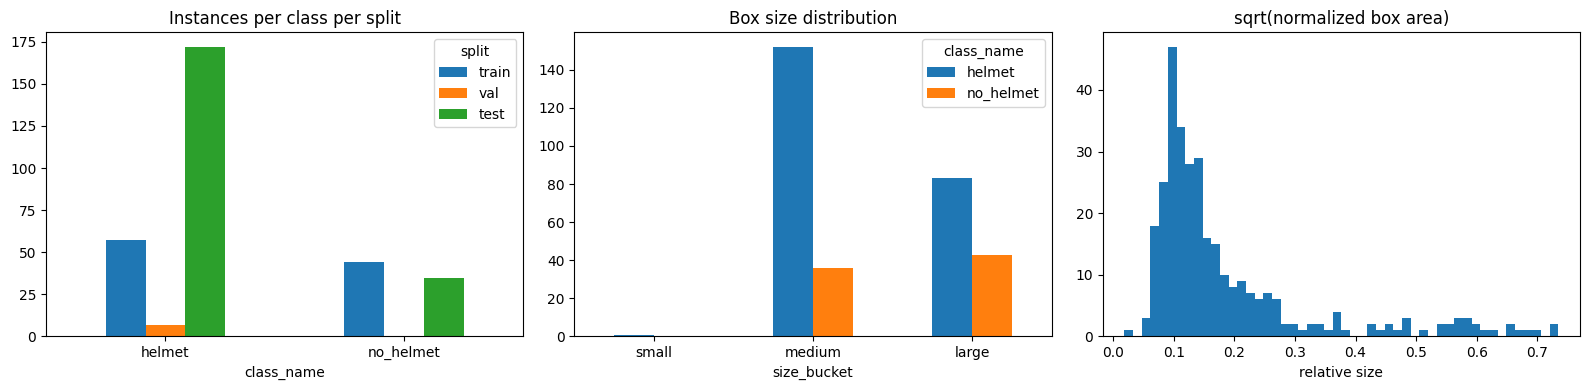

'small' boxes: 0.3%


In [13]:
# ── Box-size distribution: validates the PRD §4 head-size assumption ─────────
import matplotlib.pyplot as plt

# Absolute pixel size needs image dims; normalized w*h is a good proxy for the size slices.
boxes["area_norm"] = boxes.w * boxes.h
boxes["size_bucket"] = pd.cut(
    boxes.area_norm ** 0.5, bins=[0, 0.05, 0.15, 1.0], labels=["small", "medium", "large"]
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
counts.drop(columns="TOTAL").plot.bar(ax=axes[0], title="Instances per class per split", rot=0)
boxes.groupby(["size_bucket", "class_name"], observed=True).size().unstack(fill_value=0).plot.bar(
    ax=axes[1], title="Box size distribution", rot=0)
axes[2].hist(boxes.area_norm ** 0.5, bins=50)
axes[2].set_title("sqrt(normalized box area)"); axes[2].set_xlabel("relative size")
plt.tight_layout(); plt.show()

small_share = (boxes.size_bucket == "small").mean()
print(f"'small' boxes: {small_share:.1%}")
if small_share > 0.30:
    print("🟡 Many small boxes → raise img_size 640→960 BEFORE reaching for a bigger model (TDD §2).")

## 3 · Training configuration

Everything comes from `configs/training.yaml` (TDD §4). **Do not hardcode hyperparameters here** —
the config file is the record of what produced a given result, and a value typed into a notebook
cell is a value nobody can reproduce.

In [14]:
train_cfg = load_config("training")
print(yaml.safe_dump(train_cfg, sort_keys=False))

epochs: 100
batch_size: 16
lr: 0.001
seed: 42
img_size: 640
patience: 20
base_weights: yolo11n.pt
augmentation:
  hflip: 0.5
  flipud: 0.0
  mosaic: 1.0
  mixup: 0.1
  hsv_h: 0.015
  hsv_s: 0.7
  hsv_v: 0.4
  degrees: 10.0
  perspective: 0.0005
tracking:
  backend: wandb
  project: null



In [15]:
# Map our config onto Ultralytics kwargs. Augmentation policy per TDD §3.
aug = train_cfg.get("augmentation", {}) or {}

BASE_WEIGHTS = train_cfg.get("base_weights") or "yolo11n.pt"

train_kwargs = dict(
    data=str(YOLO_YAML_PATH),
    epochs=train_cfg.get("epochs", 100),
    batch=train_cfg.get("batch_size", 16),
    imgsz=train_cfg.get("img_size", 640),
    lr0=train_cfg.get("lr", 0.001),
    seed=train_cfg.get("seed", SEED),
    patience=train_cfg.get("patience", 20),
    project="outputs/training",
    name=f"helmet-{GIT_COMMIT}",
    exist_ok=True,
    # Augmentation (TDD §3)
    fliplr=aug.get("hflip", aug.get("fliplr", 0.5)),
    flipud=aug.get("flipud", 0.0),      # DISABLED: fixed camera orientation; upside-down heads never occur
    mosaic=aug.get("mosaic", 1.0),
    mixup=aug.get("mixup", 0.1),
    hsv_h=aug.get("hsv_h", 0.015),
    hsv_s=aug.get("hsv_s", 0.7),
    hsv_v=aug.get("hsv_v", 0.4),
    degrees=aug.get("degrees", 10.0),
    perspective=aug.get("perspective", 0.0005),
)

print(f"base weights : {BASE_WEIGHTS}")
for k, v in train_kwargs.items():
    print(f"  {k:12s} = {v}")

if train_kwargs["flipud"] != 0.0:
    print("\n⚠️  flipud != 0 — TDD §3 disables it deliberately (fixed camera orientation).")

base weights : yolo11n.pt
  data         = /content/drive/MyDrive/Data Science/Computer Vision/helmet-detection-system/configs/yolo_dataset.yaml
  epochs       = 100
  batch        = 16
  imgsz        = 640
  lr0          = 0.001
  seed         = 42
  patience     = 20
  project      = outputs/training
  name         = helmet-775b686
  exist_ok     = True
  fliplr       = 0.5
  flipud       = 0.0
  mosaic       = 1.0
  mixup        = 0.1
  hsv_h        = 0.015
  hsv_s        = 0.7
  hsv_v        = 0.4
  degrees      = 10.0
  perspective  = 0.0005


In [16]:
# ── Experiment tracking ──────────────────────────────────────────────────────
# ⚠️ PRD OQ3: W&B media logging uploads FRAMES OF WORKERS to a third party.
# If OQ3 resolved to on-prem-only, leave backend as "none" or disable media.
tracking = (train_cfg.get("tracking") or {})
backend = tracking.get("backend", "none")

if backend == "wandb":
    print("⚠️  W&B enabled. Confirm OQ3 permits factory frames leaving the premises.")
    print("    To keep metrics but not images: os.environ['WANDB_LOG_IMAGES'] = 'false'")
    import wandb  # noqa: F401
    from ultralytics import settings; settings.update({"wandb": True})
else:
    from ultralytics import settings; settings.update({"wandb": False})
    print("Tracking: local only (outputs/training/).")

⚠️  W&B enabled. Confirm OQ3 permits factory frames leaving the premises.
    To keep metrics but not images: os.environ['WANDB_LOG_IMAGES'] = 'false'


## 4 · Training with live epoch tracking

A callback prints per-epoch metrics as they land, so you can kill a bad run early instead of
paying for 100 epochs to learn it diverged at epoch 3.

The callback is wrapped in `try/except`: a plotting bug must never take down a long training run.

In [17]:
from ultralytics import YOLO
from IPython.display import clear_output

history = []

def _on_fit_epoch_end(trainer):
    """Collect + display metrics each epoch. Never allowed to raise."""
    try:
        m = {k.split("/")[-1].replace("(B)", ""): float(v)
             for k, v in (trainer.metrics or {}).items()}
        m["epoch"] = int(trainer.epoch) + 1
        history.append(m)

        h = pd.DataFrame(history)
        clear_output(wait=True)
        cols = [c for c in ["epoch", "precision", "recall", "mAP50", "mAP50-95"] if c in h.columns]
        print(h[cols].tail(10).to_string(index=False))

        if len(h) >= 2 and "mAP50" in h.columns:
            fig, ax = plt.subplots(figsize=(7, 3))
            for c in [c for c in ("mAP50", "mAP50-95", "precision", "recall") if c in h.columns]:
                ax.plot(h.epoch, h[c], label=c, marker=".")
            ax.axhline(0.85, ls="--", c="r", lw=1, label="mAP50 target (PRD §2.1)")
            ax.set_xlabel("epoch"); ax.set_ylim(0, 1); ax.legend(fontsize=8); ax.grid(alpha=.3)
            plt.tight_layout(); plt.show()
    except Exception as e:
        print(f"[callback error, training continues] {e}")

model = YOLO(BASE_WEIGHTS)          # COCO-pretrained; never train from scratch (Phase 2.3)
model.add_callback("on_fit_epoch_end", _on_fit_epoch_end)
print(f"Loaded {BASE_WEIGHTS}. Starting training…")

Loaded yolo11n.pt. Starting training…


 epoch  precision   recall    mAP50  mAP50-95
    29   0.832340 0.710030 0.756280  0.325420
    30   0.823360 0.714290 0.717920  0.374580
    31   0.816160 0.714290 0.687670  0.362580
    32   0.702190 0.714290 0.653140  0.244270
    33   0.474540 0.520520 0.482310  0.233960
    34   0.514610 0.714290 0.606250  0.336720
    35   0.575460 0.714290 0.603160  0.335910
    36   0.709820 0.571430 0.617720  0.307090
    37   0.971720 0.428570 0.591150  0.301180
    38   0.385223 0.714286 0.716183  0.406532


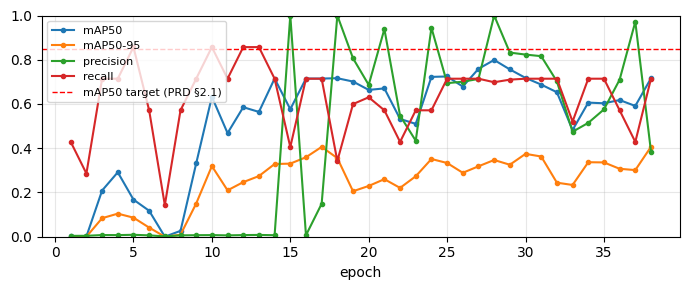

wandb: WARNING Tried to log to step 37 that is less than the current step 39. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.


lr/pg0,▁▂▂▃▃▃▄▄▅▅▆▆▇▇▇███████▇▇▇▇▇▇▇▇▇▇▇▇▆▆▆
lr/pg1,▁▂▂▃▃▃▄▄▅▅▆▆▇▇▇███████▇▇▇▇▇▇▇▇▇▇▇▇▆▆▆
lr/pg2,▁▂▂▃▃▃▄▄▅▅▆▆▇▇▇███████▇▇▇▇▇▇▇▇▇▇▇▇▆▆▆
metrics/mAP50(B),▁▁▃▄▂▂▁▁▄▇▅▆▆▇▆▇▇▇▇▇▇▆▅▇▇▇███▇▇▇▅▆▆▆▆▇
metrics/mAP50-95(B),▁▁▂▃▂▂▁▁▄▆▅▅▆▇▇▇█▇▅▅▅▅▆▇▇▆▆▇▇▇▇▅▅▇▇▆▆█
metrics/precision(B),▁▁▁▁▁▁▁▁▁▁▁▁▁▁█▁▂█▇▆█▅▄█▆▆▆█▇▇▇▆▄▅▅▆█▄
metrics/recall(B),▄▂▇▇█▅▁▅▇█▇██▇▄▇▇▃▅▆▅▄▅▅▇▇▇▆▇▇▇▇▅▇▇▅▄▇
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
+6,...



✅ Training done. Run dir: /content/drive/MyDrive/Data Science/Computer Vision/helmet-detection-system/runs/detect/outputs/training/helmet-775b686


In [18]:
# ── Train ────────────────────────────────────────────────────────────────────
# Long-running. Run Section 9 (persist artifacts) as soon as this finishes.
results = model.train(**train_kwargs)

RUN_DIR = Path(results.save_dir if hasattr(results, "save_dir") else train_kwargs["project"])
print("\n✅ Training done. Run dir:", RUN_DIR)

## 5 · Training metrics visualization

The **loss curves are a gate**, not a picture (implementation plan, Phase 2 gate). What to look for:

- **Diverging / NaN loss** → lower `lr`, check batch size.
- **Val loss rising while train loss falls** → overfitting; more data or stronger augmentation.
- **Both classes near-zero mAP** → suspect a *data pipeline bug* (label format, class-id mapping,
  paths), **not** the model. Verify by deliberately overfitting 10 images: if it can't memorize
  10 images, it's wiring, not learning.

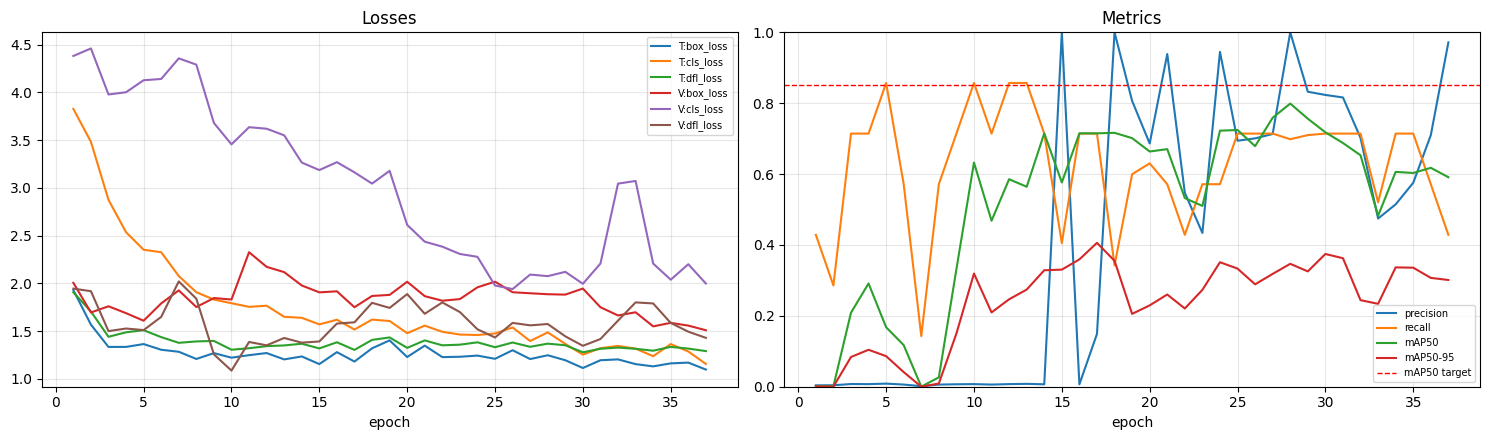


Final-epoch metrics:
 metrics/precision(B)    0.97172
metrics/recall(B)       0.42857
metrics/mAP50(B)        0.59115
metrics/mAP50-95(B)     0.30118


In [19]:
results_csv = RUN_DIR / "results.csv"
hist = pd.read_csv(results_csv)
hist.columns = [c.strip() for c in hist.columns]

loss_cols = [c for c in hist.columns if "loss" in c]
metric_cols = [c for c in hist.columns if c.startswith("metrics/")]

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
for c in loss_cols:
    axes[0].plot(hist.index + 1, hist[c], label=c.replace("train/", "T:").replace("val/", "V:"))
axes[0].set_title("Losses"); axes[0].set_xlabel("epoch"); axes[0].legend(fontsize=7); axes[0].grid(alpha=.3)

for c in metric_cols:
    axes[1].plot(hist.index + 1, hist[c], label=c.replace("metrics/", "").replace("(B)", ""))
axes[1].axhline(0.85, ls="--", c="r", lw=1, label="mAP50 target")
axes[1].set_title("Metrics"); axes[1].set_xlabel("epoch"); axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=7); axes[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

# Automated sanity checks on the curves.
tr = [c for c in loss_cols if c.startswith("train/")]
va = [c for c in loss_cols if c.startswith("val/")]
if tr and va and len(hist) > 10:
    t_last, v_last = hist[tr].sum(axis=1), hist[va].sum(axis=1)
    n = max(len(hist) // 4, 2)
    if v_last.iloc[-n:].mean() > v_last.iloc[:n].mean():
        print("🟡 Val loss ended higher than it started → possible overfitting.")
    if t_last.isna().any() or (t_last > 1e4).any():
        print("🔴 Train loss diverged/NaN → lower lr0.")
final_map = hist[[c for c in metric_cols if "mAP50(B)" in c or "mAP50" in c]].iloc[-1]
print("\nFinal-epoch metrics:\n", hist[metric_cols].iloc[-1].to_string())

## 6 · Validation metrics + threshold selection

**This is your iteration surface.** Tune here, re-run here, as often as you like — val is what
it's for.

Threshold selection follows PRD §7 / TDD §5: pick the **lowest** confidence threshold that still
holds `no_helmet` **precision ≥ 0.90**, maximizing recall under that floor.

**Do not ship the F1-optimal point.** F1 treats a missed violation and a false alarm as equally
bad. PRD §7 says they are not: a missed violation is silent and is the failure the system exists
to prevent.

In [20]:
val_res = model.val(data=str(YOLO_YAML_PATH), split="val", imgsz=train_kwargs["imgsz"])

def per_class_table(res) -> pd.DataFrame:
    """Per-class P/R/mAP. Ultralytics' box.class_result(i) -> (p, r, ap50, ap50_95)."""
    rows = []
    for i, name in enumerate(CLASS_NAMES):
        try:
            p, r, ap50, ap = res.box.class_result(i)
        except Exception as e:
            print(f"[class_result({i}) failed: {e}] — check the ultralytics API for this version.")
            p = r = ap50 = ap = float("nan")
        rows.append({"class": name, "precision": p, "recall": r, "mAP50": ap50, "mAP50-95": ap})
    return pd.DataFrame(rows).set_index("class")

val_table = per_class_table(val_res)
print("Validation, per class:")
print(val_table.round(4).to_string())
print(f"\nOverall  mAP50={val_res.box.map50:.4f}  mAP50-95={val_res.box.map:.4f}")

Ultralytics 8.4.96 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,542 parameters, 0 gradients, 6.3 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.6±0.3 ms, read: 13.8±3.0 MB/s, size: 27.4 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/drive/MyDrive/Data Science/Computer Vision/helmet-detection-system/data/processed/val/labels.cache... 5 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5/5 1.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 8.7it/s 0.1s
                   all          5          7      0.149      0.714      0.715      0.406
                helmet          5          7      0.149      0.714      0.715      0.406
Speed: 0.3ms preprocess, 9.9ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to

In [21]:
# ── Threshold sweep on VAL (never test) ──────────────────────────────────────
import numpy as np

PRECISION_FLOOR = 0.90   # PRD §2.1 — a floor, not a target

sweep = []
for t in np.round(np.arange(0.05, 0.91, 0.05), 2):
    r = model.val(data=str(YOLO_YAML_PATH), split="val", conf=float(t),
                  imgsz=train_kwargs["imgsz"], verbose=False, plots=False)
    try:
        p, rc, ap50, _ = r.box.class_result(NO_HELMET_IDX)
    except Exception:
        p = rc = ap50 = float("nan")
    sweep.append({"conf": t, "precision": p, "recall": rc, "mAP50": ap50})

sweep_df = pd.DataFrame(sweep)
sweep_df["f1"] = 2 * sweep_df.precision * sweep_df.recall / (sweep_df.precision + sweep_df.recall)
print("no_helmet sweep on val:")
print(sweep_df.round(4).to_string(index=False))

Ultralytics 8.4.96 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
WARNING ⚠️ val: Slow image access detected (ping: 0.9±0.8 ms, read: 10.3±2.2 MB/s, size: 27.4 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/drive/MyDrive/Data Science/Computer Vision/helmet-detection-system/data/processed/val/labels.cache... 5 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5/5 1.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 15.7it/s 0.1s
                   all          5          7          1      0.143      0.145      0.102
Speed: 0.3ms preprocess, 3.8ms inference, 0.0ms loss, 0.5ms postprocess per image
Ultralytics 8.4.96 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
WARNING ⚠️ val: Slow image access detected (ping: 0.7±0.4 ms, read: 15.3±4.0 MB/s, size: 27.4 KB). Use l

🔴 No threshold reaches precision ≥ 0.9 for no_helmet, and no F1-optimal point can be found (all F1 values are NaN).
   PRD §2.1 unmet at every operating point → Phase 3.6 optimization loop.
   (Falling back to a default confidence of 0.05 only so later cells run.)


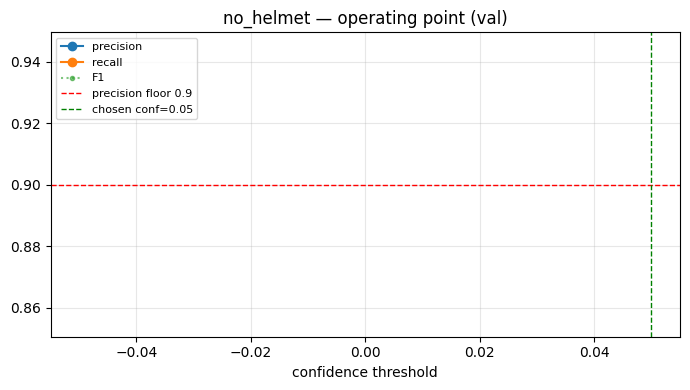

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# ── Pick the operating threshold ─────────────────────────────────────────────
ok = sweep_df[sweep_df.precision >= PRECISION_FLOOR]

if ok.empty:
    if sweep_df.f1.isnull().all():
        # All f1 values are NaN, cannot find idxmax. Fallback to the first available confidence threshold or a default.
        chosen = float(sweep_df.conf.iloc[0]) if not sweep_df.empty else 0.5
        print(f"🔴 No threshold reaches precision \u2265 {PRECISION_FLOOR} for no_helmet, and no F1-optimal point can be found (all F1 values are NaN).")
        print(f"   PRD \u00a72.1 unmet at every operating point \u2192 Phase 3.6 optimization loop.")
        print(f"   (Falling back to a default confidence of {chosen} only so later cells run.)")
    else:
        # Some f1 values are not NaN, so idxmax can be found.
        chosen = float(sweep_df.loc[sweep_df.f1.idxmax(), "conf"])
        print(f"🔴 No threshold reaches precision \u2265 {PRECISION_FLOOR} for no_helmet.")
        print(f"   PRD \u00a72.1 unmet at every operating point \u2192 Phase 3.6 optimization loop.")
        print(f"   (Falling back to F1-optimal {chosen} only so later cells run.)")
else:
    chosen = float(ok.loc[ok.recall.idxmax(), "conf"])   # max recall subject to the precision floor
    row = ok.loc[ok.recall.idxmax()]
    print(f"🟢 Chosen conf_threshold = {chosen}")
    print(f"   no_helmet precision={row.precision:.4f} (\u2265{PRECISION_FLOOR}), recall={row.recall:.4f})")

    # Also handle f1.idxmax() being NaN here if sweep_df.f1 is all NaN
    f1_opt = float(sweep_df.loc[sweep_df.f1.idxmax(), "conf"]) if not sweep_df.f1.isnull().all() else chosen
    if f1_opt != chosen:
        print(f"   (F1-optimal would be {f1_opt} \u2014 deliberately NOT chosen, per PRD \u00a77.)")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sweep_df.conf, sweep_df.precision, marker="o", label="precision")
ax.plot(sweep_df.conf, sweep_df.recall, marker="o", label="recall")
ax.plot(sweep_df.conf, sweep_df.f1, marker=".", ls=":", label="F1", alpha=.6)
ax.axhline(PRECISION_FLOOR, ls="--", c="r", lw=1, label=f"precision floor {PRECISION_FLOOR}")
ax.axvline(chosen, ls="--", c="g", lw=1, label=f"chosen conf={chosen}")
ax.set_xlabel("confidence threshold"); ax.set_title("no_helmet \u2014 operating point (val)")
ax.legend(fontsize=8); ax.grid(alpha=.3); plt.tight_layout(); plt.show()

CHOSEN_CONF = chosen

In [25]:
# Write the chosen threshold into configs/inference.yaml (TDD §7).
# This is what ml/inference and the API will read — the notebook's real output, besides weights.
inf_cfg = load_config("inference")
inf_cfg["conf_threshold"] = CHOSEN_CONF
inf_cfg["alert_conf_threshold"] = CHOSEN_CONF   # PRD §7: tune separately later if alert fatigue appears

with open(ROOT / "configs" / "inference.yaml", "w") as f:
    yaml.safe_dump(inf_cfg, f, sort_keys=False)
print(yaml.safe_dump(inf_cfg, sort_keys=False))
print("→ Commit configs/inference.yaml. Record the sweep in docs/reports/.")

model_weights: ml/models/best.pt
img_size: 640
conf_threshold: 0.05
iou_threshold: 0.5
device: auto
alert_conf_threshold: 0.05

→ Commit configs/inference.yaml. Record the sweep in docs/reports/.


## 7 · Model evaluation — the TEST split ⛔ **Run once**

**Everything above this line used `val`. This section is the acceptance measurement.**

Merging Phase 2 and Phase 3 into one notebook removed the gate that used to stand here, so the
discipline is now yours to keep: each time you run this cell and then change something in response,
you leak a little test information into your decisions. Do it a few times and the test split stops
measuring generalization and starts measuring how well you tuned against it — and PRD §2.1 becomes
a number you cannot defend to anyone.

**Set `RUN_TEST_EVAL = True` only when you believe you are done iterating.**
If it fails, go back to Section 6 and the Phase 3.6 loop — don't re-run this cell until the next
genuine candidate.

In [26]:
RUN_TEST_EVAL = False   # ← flip to True deliberately, not habitually

if not RUN_TEST_EVAL:
    print("Skipped. Iterate on val (Section 6); set RUN_TEST_EVAL=True when you're done.")
else:
    test_res = model.val(data=str(YOLO_YAML_PATH), split="test",
                         conf=CHOSEN_CONF, imgsz=train_kwargs["imgsz"])
    test_table = per_class_table(test_res)
    print("TEST, per class:")
    print(test_table.round(4).to_string())
    print(f"\nOverall  mAP50={test_res.box.map50:.4f}  mAP50-95={test_res.box.map:.4f}")

Skipped. Iterate on val (Section 6); set RUN_TEST_EVAL=True when you're done.


In [27]:
# ── Judge against PRD §2.1, number by number ─────────────────────────────────
if RUN_TEST_EVAL:
    nh = test_table.loc["no_helmet"]
    checks = [
        ("mAP50 (all)",              float(test_res.box.map50), 0.85),
        ("mAP50-95 (all)",           float(test_res.box.map),   0.55),
        ("Precision (no_helmet)",    float(nh.precision),       0.90),
        ("Recall (no_helmet)",       float(nh.recall),          0.90),
    ]
    scorecard = pd.DataFrame(
        [{"metric": m, "target": f"≥ {t}", "actual": round(a, 4), "pass": "✅" if a >= t else "❌"}
         for m, a, t in checks]
    )
    print(scorecard.to_string(index=False))

    gating_failed = [m for m, a, t in checks if a < t]
    if gating_failed:
        print(f"\n🔴 PRD §2.1 NOT met: {gating_failed}")
        print("   → Phase 3.6 loop, in leverage order:")
        print("     more data → better annotation → better augmentation → img_size 640→960")
        print("     → hyperparameters → only then a bigger model (11n→11s→11m).")
        print("   Do NOT proceed to Phase 4 with an unmet gate without the user explicitly")
        print("   accepting the documented shortfall (implementation plan, Phase 3 gate).")
    else:
        print("\n🟢 PRD §2.1 met on the test split. Phase 3 gate satisfied.")
        print("   Note: the per-class no_helmet rows are the gate, not just mAP50.")

In [28]:
# ── Evaluation slices (TDD §5) — aggregates hide the failures that matter ────
if RUN_TEST_EVAL:
    # Per-session slice: the leakage / scene-memorization detector.
    print("Per-session slice — build one YOLO yaml per session and val() it, or inspect")
    print("predictions grouped by session below in Section 8. A session scoring far above")
    print("the rest means leakage (R4) or the model learned a scene, not the task (R10).\n")

    # Negative-sample false-alarm rate — directly measures the PRD §2.1 ≤5% target.
    test_neg = df[(df.split == "test") & (df.cls.isna())].image.unique()
    if len(test_neg):
        fp_images = 0
        for name in test_neg:
            pred = model.predict(str(PROCESSED / "test" / "images" / name),
                                 conf=CHOSEN_CONF, verbose=False)[0]
            if len(pred.boxes):
                fp_images += 1
        fa_rate = fp_images / len(test_neg)
        print(f"False-alarm rate on {len(test_neg)} negative samples: {fa_rate:.1%} "
              f"{'✅' if fa_rate <= 0.05 else '❌'} (target ≤ 5%)")
    else:
        print("🟡 No negative samples in test — the ≤5% false-alarm target is unmeasurable.")
        print("   Phase 1 Slice 1.2 requires them; add negatives and re-split.")

## 8 · Error analysis

**Look at the failing images**, not just the numbers (Phase 3.4). The categories you find here are
what the Phase 3.6 loop targets — "recall is low" is not actionable, "recall is low on small
backlit heads" is.

Categorize: false positives · **false negatives** (the expensive error, PRD §7) · small objects ·
occlusion · lighting · confusers (caps, hairnets).

In [29]:
# Match predictions to ground truth by IoU to surface FPs and FNs.
def xywhn_to_xyxy(b, W, H):
    _, cx, cy, w, h = b
    return [(cx - w / 2) * W, (cy - h / 2) * H, (cx + w / 2) * W, (cy + h / 2) * H]

def iou(a, b):
    x1, y1 = max(a[0], b[0]), max(a[1], b[1])
    x2, y2 = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    ua = (a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - inter
    return inter / ua if ua > 0 else 0.0

IOU_MATCH = 0.5
split_for_errors = "test" if RUN_TEST_EVAL else "val"
print(f"Error analysis on: {split_for_errors}")

img_dir = PROCESSED / split_for_errors / "images"
lbl_dir = PROCESSED / split_for_errors / "labels"
errors = []

for img_path in sorted(p for p in img_dir.iterdir() if p.suffix.lower() in IMG_EXT):
    pred = model.predict(str(img_path), conf=CHOSEN_CONF, verbose=False)[0]
    H, W = pred.orig_shape
    gts = [(int(b[0]), xywhn_to_xyxy(b, W, H)) for b in read_label(lbl_dir / f"{img_path.stem}.txt")]
    prs = [(int(c), xyxy) for c, xyxy in
           zip(pred.boxes.cls.tolist(), pred.boxes.xyxy.tolist())]

    matched_gt, matched_pr = set(), set()
    for gi, (gc, gb) in enumerate(gts):
        for pi, (pc, pb) in enumerate(prs):
            if pi in matched_pr or pc != gc:
                continue
            if iou(gb, pb) >= IOU_MATCH:
                matched_gt.add(gi); matched_pr.add(pi); break

    for gi, (gc, gb) in enumerate(gts):
        if gi not in matched_gt:
            errors.append({"image": img_path.name, "type": "FN", "class": CLASS_NAMES[gc],
                           "box": gb, "area": (gb[2]-gb[0])*(gb[3]-gb[1])})
    for pi, (pc, pb) in enumerate(prs):
        if pi not in matched_pr:
            errors.append({"image": img_path.name, "type": "FP", "class": CLASS_NAMES[pc],
                           "box": pb, "area": (pb[2]-pb[0])*(pb[3]-pb[1])})

err_df = pd.DataFrame(errors)
if err_df.empty:
    print("No errors at this threshold — suspiciously good; verify the matcher.")
else:
    print(err_df.pivot_table(index="class", columns="type", values="image",
                             aggfunc="count", fill_value=0).to_string())

Error analysis on: val
type    FN
class     
helmet   6


In [30]:
# ── FN size breakdown: are misses concentrated in small heads? (→ img_size 960) ──
if not err_df.empty:
    err_df["side_px"] = err_df.area ** 0.5
    err_df["size_bucket"] = pd.cut(err_df.side_px, bins=[0, 32, 96, 1e9],
                                   labels=["<32px", "32-96px", ">96px"])
    print("Errors by object size:")
    print(err_df.pivot_table(index="size_bucket", columns="type", values="image",
                             aggfunc="count", fill_value=0, observed=False).to_string())

    fn_nh = err_df[(err_df.type == "FN") & (err_df["class"] == "no_helmet")]
    if len(fn_nh):
        small_share = (fn_nh.side_px < 32).mean()
        print(f"\nno_helmet FNs: {len(fn_nh)} — {small_share:.0%} are <32px")
        if small_share > 0.4:
            print("→ Misses concentrate in SMALL heads: raise img_size 640→960 first (TDD §2),")
            print("  before reaching for a bigger model. Cheaper and targets the actual failure.")

Errors by object size:
type         FN
size_bucket    
<32px         1
32-96px       5
>96px         0


In [31]:
# ── Look at the worst failures: missed no_helmet = the expensive error (PRD §7) ──
import matplotlib.patches as patches
from PIL import Image

fn_nh = err_df[(err_df.type == "FN") & (err_df["class"] == "no_helmet")] if not err_df.empty else pd.DataFrame()
show = fn_nh.head(9)

if len(show):
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    for ax, (_, r) in zip(axes.ravel(), show.iterrows()):
        ax.imshow(Image.open(img_dir / r.image)); ax.axis("off")
        x1, y1, x2, y2 = r.box
        ax.add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, ec="red", lw=2))
        ax.set_title(f"MISSED no_helmet\n{r.image[:26]} ({r.side_px:.0f}px)", fontsize=8)
    for ax in axes.ravel()[len(show):]:
        ax.axis("off")
    plt.suptitle("False negatives on no_helmet — every one of these is a missed violation", fontsize=12)
    plt.tight_layout(); plt.show()
    print("Categorize these by hand: small? occluded? backlit? motion-blurred? cap-like?")
    print("The dominant category is what the Phase 3.6 loop should target.")
else:
    print("No no_helmet false negatives at this threshold.")

No no_helmet false negatives at this threshold.


confusion_matrix_normalized.png


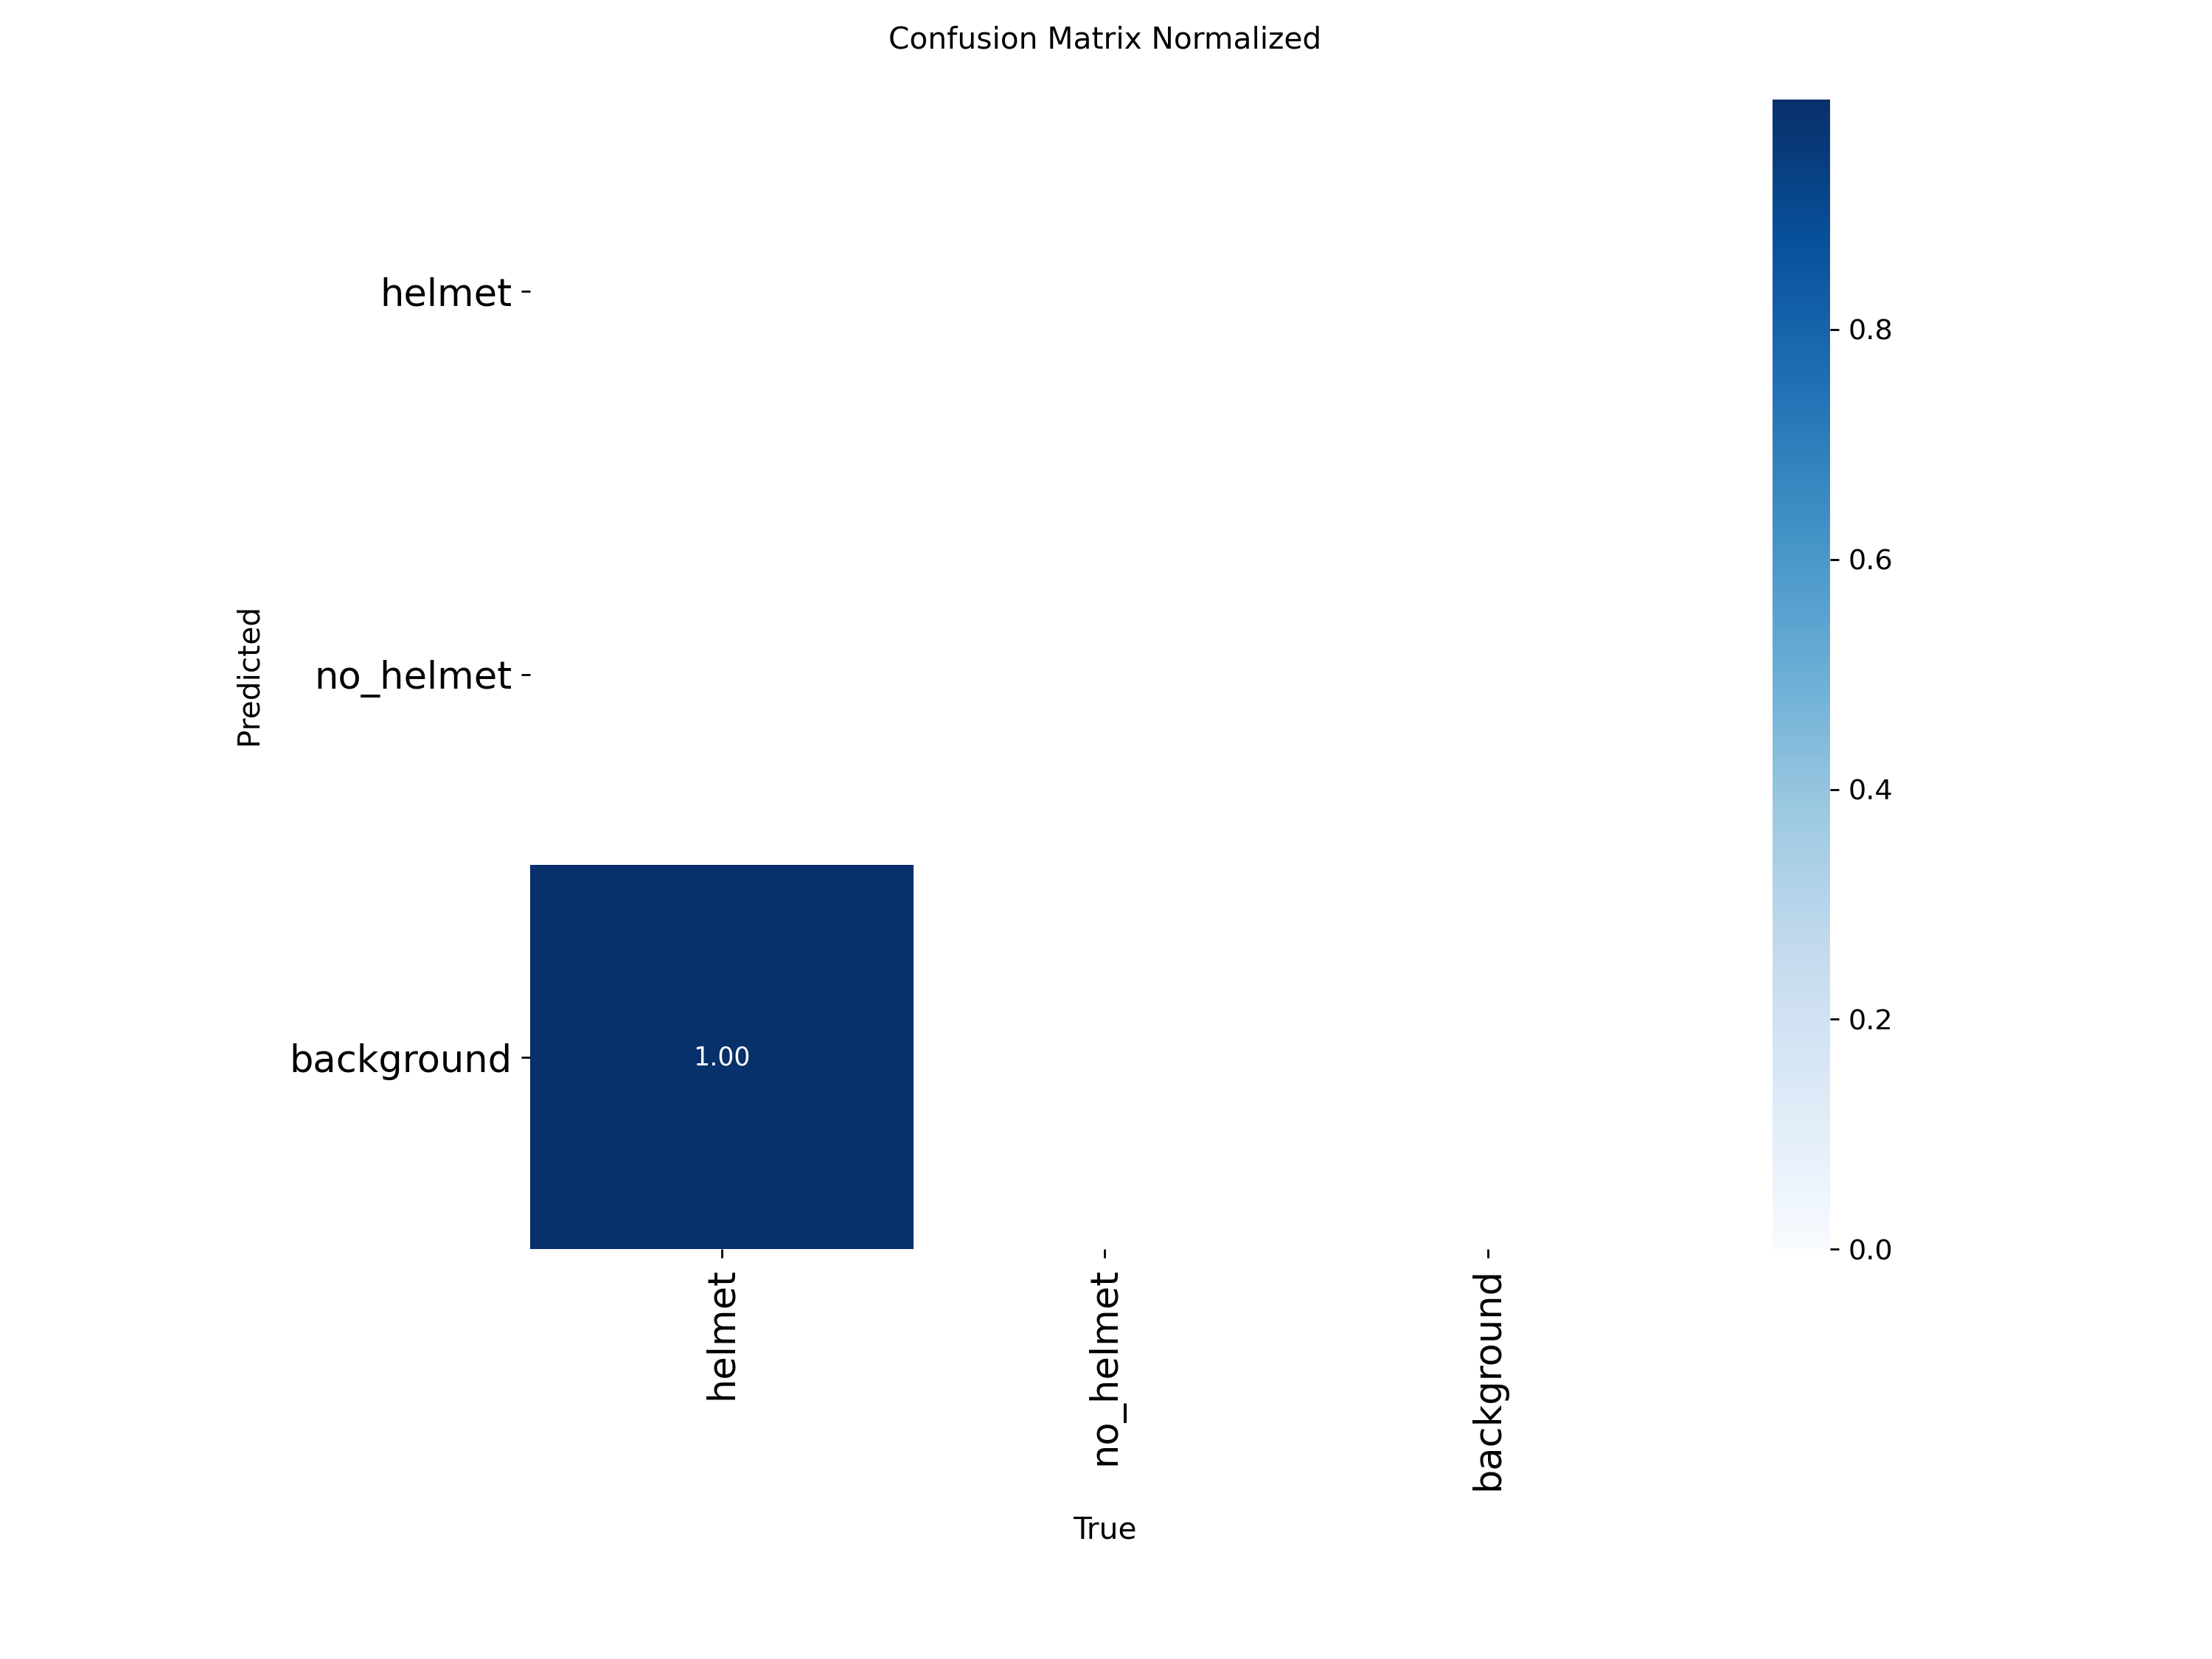

In [32]:
# Confusion matrix + PR curves that Ultralytics already wrote to the run dir.
from IPython.display import Image as IPyImage, display
for plot in ["confusion_matrix_normalized.png", "PR_curve.png", "R_curve.png"]:
    p = RUN_DIR / plot
    if p.exists():
        print(plot); display(IPyImage(filename=str(p), width=560))

## 9 · Save `best.pt` + run metadata ⚠️ **Run as soon as training finishes**

Colab VMs are reclaimed without warning — a weights file that exists only on the VM is one
disconnect away from a re-run. This section is the one-way door.

Per TDD §4 / Model Management:
- `ml/models/best.pt` — the **currently blessed** model (gitignored, overwritten on promotion)
- `artifacts/checkpoints/<version>/` — this run's checkpoints (gitignored)
- `artifacts/experiment_results/<version>/metadata.json` — **committed**. A weight file without
  one is a mystery you will re-train from scratch in six months.

In [ ]:
import shutil, json, datetime

VERSION = f"v1-{GIT_COMMIT}"      # bump per promoted run
weights_src = RUN_DIR / "weights"

ckpt_dir = ROOT / "artifacts" / "checkpoints" / VERSION
ckpt_dir.mkdir(parents=True, exist_ok=True)
for w in ("best.pt", "last.pt"):
    if (weights_src / w).exists():
        shutil.copy2(weights_src / w, ckpt_dir / w)
if (RUN_DIR / "results.csv").exists():
    shutil.copy2(RUN_DIR / "results.csv", ckpt_dir / "results.csv")
print("Checkpoints →", ckpt_dir)

# Promote to the blessed slot (only if this run is the winner).
PROMOTE = True
if PROMOTE:
    models_dir = ROOT / "ml" / "models"; models_dir.mkdir(parents=True, exist_ok=True)
    for w in ("best.pt", "last.pt"):
        if (weights_src / w).exists():
            shutil.copy2(weights_src / w, models_dir / w)
    print("Promoted → ml/models/best.pt")

In [ ]:
# ── metadata.json — committed; the traceability record (TDD §4) ──────────────
eval_split = "test" if RUN_TEST_EVAL else "val"
eval_tbl = test_table if RUN_TEST_EVAL else val_table
eval_res = test_res if RUN_TEST_EVAL else val_res

metadata = {
    "model_name": "helmet-detector",
    "version": VERSION,
    "task": "object-detection",
    "architecture": BASE_WEIGHTS.replace(".pt", ""),
    "base_weights": f"{BASE_WEIGHTS} (COCO pretrained)",
    "training_date": datetime.date.today().isoformat(),
    "trained_by": os.environ.get("USER", "argha"),
    "git_commit": GIT_COMMIT,
    "git_dirty": DIRTY,
    "dataset": {
        "name": "helmet-poc",
        "version": data_cfg.get("version", "v1"),
        "location": str(PROCESSED),
        "num_train_images": int(df[df.split == "train"].image.nunique()),
        "num_val_images": int(df[df.split == "val"].image.nunique()),
        "num_test_images": int(df[df.split == "test"].image.nunique()),
        "classes": CLASS_NAMES,
        "instances_per_class": {k: int(v) for k, v in counts["TOTAL"].items()},
    },
    "hyperparameters": {k: train_kwargs[k] for k in
                        ("epochs", "batch", "imgsz", "lr0", "seed", "patience")},
    "augmentation": {k: train_kwargs[k] for k in
                     ("fliplr", "flipud", "mosaic", "mixup", "hsv_h", "hsv_s", "hsv_v", "degrees")},
    "operating_point": {"conf_threshold": CHOSEN_CONF,
                        "selected_on": "val",
                        "rule": "lowest conf with no_helmet precision >= 0.90, max recall (PRD §7)"},
    "metrics": {
        "eval_set": f"helmet-poc/{eval_split}",
        "mAP50": round(float(eval_res.box.map50), 4),
        "mAP50-95": round(float(eval_res.box.map), 4),
        "per_class": {c: {k: (None if pd.isna(v) else round(float(v), 4))
                          for k, v in eval_tbl.loc[c].items()} for c in eval_tbl.index},
    },
    "exports": [],
    "notes": ("Evaluated on VAL only — test not yet run; PRD §2.1 not formally judged."
              if not RUN_TEST_EVAL else "Evaluated on held-out test split."),
}

meta_dir = ROOT / "artifacts" / "experiment_results" / VERSION
meta_dir.mkdir(parents=True, exist_ok=True)
meta_path = meta_dir / "metadata.json"
meta_path.write_text(json.dumps(metadata, indent=2))
print(json.dumps(metadata, indent=2)[:1600], "…")
print("\n→", meta_path, "— COMMIT this file.")

## 10 · Export the trained model

Per TDD §9: the API serves **`.pt`** on the POC target. **ONNX** is exported and archived for
portability. **No TensorRT** (a Jetson concern) and **no quantization** (an edge optimization that
buys little on a laptop GPU and costs accuracy PRD §2.1 has no headroom for).

In [ ]:
export_paths = []

onnx_path = model.export(format="onnx", imgsz=train_kwargs["imgsz"], opset=12)
print("ONNX:", onnx_path)

exp_dir = ROOT / "artifacts" / "exported_models"; exp_dir.mkdir(parents=True, exist_ok=True)
dst = exp_dir / f"helmet-det-{VERSION}.onnx"
shutil.copy2(onnx_path, dst); export_paths.append(str(dst))

pt_dst = exp_dir / f"helmet-det-{VERSION}.pt"
shutil.copy2(weights_src / "best.pt", pt_dst); export_paths.append(str(pt_dst))

metadata["exports"] = export_paths
meta_path.write_text(json.dumps(metadata, indent=2))
print("\nExports:", *export_paths, sep="\n  ")

In [ ]:
# ── Verify the export loads and agrees with the .pt ──────────────────────────
# Broken exports are exactly what tests/end_to_end/ catches later; catch it here instead.
sample = next(p for p in (PROCESSED / "val" / "images").iterdir() if p.suffix.lower() in IMG_EXT)

pt_pred   = model.predict(str(sample), conf=CHOSEN_CONF, verbose=False)[0]
onnx_pred = YOLO(str(dst)).predict(str(sample), conf=CHOSEN_CONF, verbose=False)[0]

print(f"sample: {sample.name}\n  .pt   detections: {len(pt_pred.boxes)}"
      f"\n  .onnx detections: {len(onnx_pred.boxes)}")
if len(pt_pred.boxes) != len(onnx_pred.boxes):
    print("🟡 Counts differ — usually benign NMS/precision differences near the threshold,")
    print("   but verify before serving ONNX anywhere.")

## ✅ Done — what to take back to the repo

**Download from Colab / verify in Drive** (the VM is temporary):

| Artifact | Destination | Committed? |
|---|---|---|
| `best.pt`, `last.pt` | `ml/models/` | ❌ gitignored |
| Checkpoints + `results.csv` | `artifacts/checkpoints/<version>/` | ❌ gitignored |
| `metadata.json` | `artifacts/experiment_results/<version>/` | ✅ **commit** |
| ONNX + `.pt` export | `artifacts/exported_models/` | ❌ → cloud storage |
| `configs/inference.yaml` (chosen threshold) | `configs/` | ✅ **commit** |
| Threshold sweep + accuracy report | `docs/reports/accuracy_report_<version>.md` | ✅ **commit** |

**Phase 2–3 gate (implementation plan):**

- [ ] Loss curves sane; no overfitting signature
- [ ] `best.pt` + `last.pt` + logs saved **off** this VM
- [ ] `metadata.json` committed, with the git commit of the training code
- [ ] Threshold selected **on val**, written to `configs/inference.yaml`
- [ ] Error analysis done; failure categories named
- [ ] **`RUN_TEST_EVAL` run once**; PRD §2.1 judged number-by-number
- [ ] PRD §2.1 met — **including per-class `no_helmet`** — **or** shortfall documented and
      explicitly accepted by the user
- [ ] `docs/reports/accuracy_report_<version>.md` written

**If PRD §2.1 is unmet** after the Phase 3.6 loop, the honest outcome is to report the shortfall
and stop — not to proceed to Phase 4. A model that misses one violation in four is worse than no
system, because it looks like it works.

**Promotion to `ml/` (implementation plan, Slice 2.2):** logic proven here gets promoted into
`ml/training/train.py` and `ml/evaluation/evaluate.py` **with tests** — notebooks never hold
production logic. `api-services/` imports `ml/`, never this notebook.